Here, we apply normalization/dimensionality reduction/batch correections to the counts matrix:

In [1]:
import time
import os

import numpy as np
import pandas as pd

from scipy import stats
from sklearn.decomposition import PCA

import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import io
from scLEMBAS import preprocess as pp

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [3]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [4]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'
seed = 888

Load the raw counts matrix (already filtered for low QC cells):

In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))

Normalize and identify HVGs:

In [5]:
%%time
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key=None, flavor = 'seurat')

CPU times: user 59.8 s, sys: 1.3 s, total: 1min 1s
Wall time: 1min 1s


In [6]:
adata

AnnData object with n_obs × n_vars = 734650 × 16227
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate', 'condition', 'drug_target', 'drug_moa'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

Run PCA: 

In [ ]:
%%time
sc.tl.pca(
    data = adata, 
    zero_center = True, # use cov matrix
    mask_var = 'highly_variable', # use hvgs
    random_state = seed)

Identify a rank from the variance ratio:

In [ ]:
n_pcs = pp._compute_elbow(adata, curve='convex', direction='decreasing')
adata.uns["pca"]['pca_rank'] = n_pcs

sc.pl.pca_variance_ratio(adata)
print('The elbow was automatically identified at PC {}'.format(n_pcs))

In [ ]:
adata.write_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))

## Covariate Associations

Use the first n_pcs to understand which covariates are most associated with PC variance:

In [5]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))

In [6]:
# r2_df_linear = pp.pc_association(
#     adata = adata,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'linear', 
#     n_cores = n_cores, 
#     seed = seed
# )

# r2_df_nl = pp.pc_association(
#     adata = adata,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'nonlinear', 
#     n_cores = n_cores, 
#     seed = seed
# )

# r2_df = pd.concat([r2_df_linear, r2_df_nl])
# r2_df.to_csv(os.path.join(data_path, 'processed', author + '_geneexpr_pc_associations.csv'))

r2_df = pd.read_csv(os.path.join(data_path, 'processed', author + '_geneexpr_pc_associations.csv'), 
                   index_col = 0)

Visualize, rank-ordered by median value:

/tmp/ipykernel_3741985/2630786968.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)
/tmp/ipykernel_3741985/2630786968.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)


''

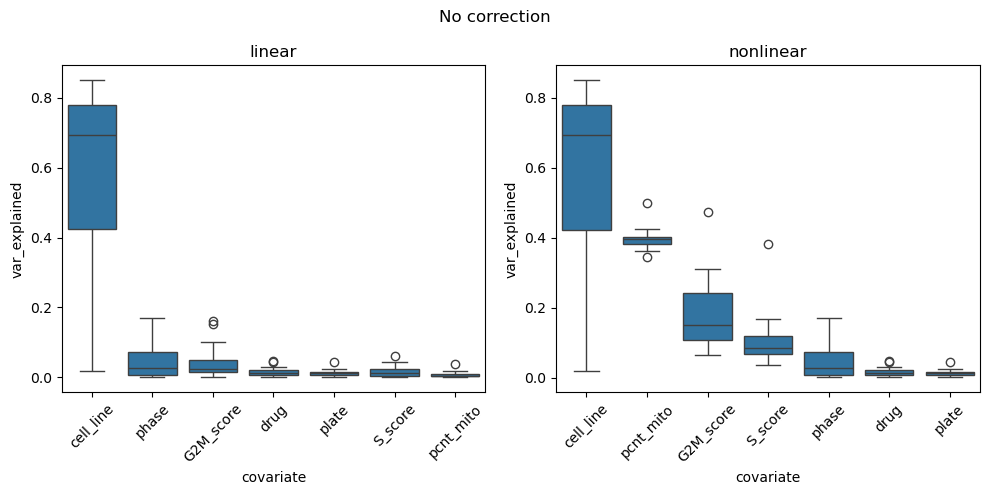

In [7]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
for i, model_type in enumerate(['linear', 'nonlinear']):
    viz_df = r2_df[r2_df.model_type == model_type]
    viz_df = viz_df.drop(columns = ['PC', 'model_type']).copy()
    
    ranked_covars = viz_df.median(axis = 0).sort_values(ascending = False).index.tolist()
    
    viz_df = pd.melt(viz_df, var_name='covariate', value_name = 'var_explained')
    viz_df.covariate = pd.Categorical(viz_df.covariate, 
                                 categories = ranked_covars, 
                                 ordered=True)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'var_explained', ax = ax[i])
    
    ax[i].set_title(model_type)
    
    xlabels = ax[i].get_xticklabels()
    ax[i].set_xticklabels(xlabels, rotation=45)

fig.suptitle('No correction')
fig.tight_layout()
;

Since cell line is strongly dominant, let's also see what these boxplots look like without that: 

/tmp/ipykernel_3741985/2726537125.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)
/tmp/ipykernel_3741985/2726537125.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)


''

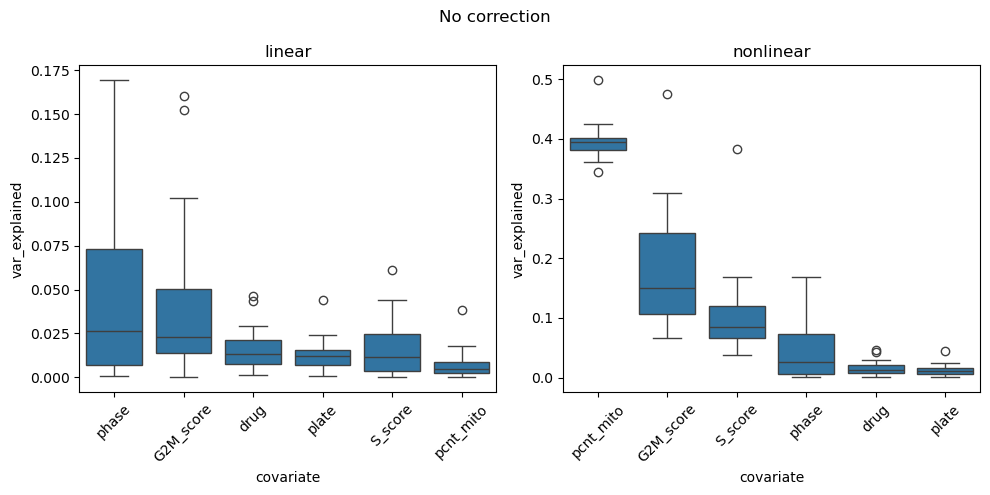

In [8]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
for i, model_type in enumerate(['linear', 'nonlinear']):
    viz_df = r2_df[r2_df.model_type == model_type]
    viz_df = viz_df.drop(columns = ['PC', 'model_type', 'cell_line']).copy()
    
    ranked_covars = viz_df.median(axis = 0).sort_values(ascending = False).index.tolist()
    
    viz_df = pd.melt(viz_df, var_name='covariate', value_name = 'var_explained')
    viz_df.covariate = pd.Categorical(viz_df.covariate, 
                                 categories = ranked_covars, 
                                 ordered=True)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'var_explained', ax = ax[i])
    
    ax[i].set_title(model_type)
    
    xlabels = ax[i].get_xticklabels()
    ax[i].set_xticklabels(xlabels, rotation=45)

fig.suptitle('No correction')
fig.tight_layout()
;

Median PC var explained values:

In [9]:
pd.melt(r2_df.set_index('PC'), id_vars='model_type', var_name='covariate').groupby(['model_type', 'covariate']).median()


value
model_type covariate          
linear     G2M_score  0.023187
           S_score    0.011637
           cell_line  0.694270
           drug       0.013358
           pcnt_mito  0.004587
           phase      0.026285
           plate      0.011880
nonlinear  G2M_score  0.150066
           S_score    0.085065
           cell_line  0.694270
           drug       0.013358
           pcnt_mito  0.394836
           phase      0.026285
           plate      0.011879

### Cell Cycle Deep Dive

Looks like drug is not a particularly strong source of variance. We will correct for these various other variance sources to capture those that we care about. First, let's look at the relationship between "phase", "G2M_score", and "S_score" since these are all indicators of cell cycle. If they're all closely associated, we probably only need to correct for one.

In [10]:
pairs = [
    ('G2M_score', 'S_score'),
    ('phase', 'G2M_score'),
    ('phase', 'S_score'),
]

for x, y in pairs:
    x_vals = adata.obs[x].cat.codes if adata.obs[x].dtype.name == 'category' else adata.obs[x]
    y_vals = adata.obs[y].cat.codes if adata.obs[y].dtype.name == 'category' else adata.obs[y]
    
    stat, pval = stats.spearmanr(x_vals, y_vals)
    print(f"Spearman({x} vs {y}): ρ = {stat:.3f}, p = {pval:.1g}")


Spearman(G2M_score vs S_score): ρ = 0.571, p = 0
Spearman(phase vs G2M_score): ρ = 0.756, p = 0
Spearman(phase vs S_score): ρ = 0.530, p = 0


Let's use a PC component that captures all 3 metrics:

In [11]:
phase_dummies = pd.get_dummies(adata.obs['phase'], prefix='phase').astype(int)
X = pd.concat([adata.obs[['S_score', 'G2M_score']], phase_dummies], axis=1)

pca_mod = PCA(n_components=1, random_state = seed)
pca_mod.fit(X) # fit to all 3 metrics

var_explained_pc1 = pca_mod.explained_variance_ratio_[0]
print(f"Variance explained by PC1 of aggregated cell cycle metrics: {var_explained_pc1:.3%}")

cell_cycle_pc1 = pca_mod.transform(X)
adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

Variance explained by PC1 of aggregated cell cycle metrics: 70.677%


In [12]:
pairs = [
    ('G2M_score', 'cell_cycle_PC1'),
    ('phase', 'cell_cycle_PC1'),
    ('S_score', 'cell_cycle_PC1'),
]

for x, y in pairs:
    x_vals = adata.obs[x].cat.codes if adata.obs[x].dtype.name == 'category' else adata.obs[x]
    y_vals = adata.obs[y].cat.codes if adata.obs[y].dtype.name == 'category' else adata.obs[y]
    
    stat, pval = stats.spearmanr(x_vals, y_vals)
    print(f"Spearman({x} vs {y}): ρ = {stat:.3f}, p = {pval:.1g}")


Spearman(G2M_score vs cell_cycle_PC1): ρ = 0.981, p = 0
Spearman(phase vs cell_cycle_PC1): ρ = 0.801, p = 0
Spearman(S_score vs cell_cycle_PC1): ρ = 0.625, p = 0


Looks like the PC well accounts for all 3 cell cycle metrics, atleast linearly. So, we will use this as our cell cycle covariate.

## Covariate correction

In [13]:
# adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))
# adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]


In [14]:
plate_dummies = pd.get_dummies(adata.obs['plate'], prefix='plate').astype(float)
for col in plate_dummies.columns:
    adata.obs[col] = plate_dummies[col]
    
batch_keys = ['pcnt_mito', 'cell_cycle_PC1'] + plate_dummies.columns.tolist()

Linear:

In [ ]:
adata_hvg = adata[:, adata.var.highly_variable].copy()
sc.pp.regress_out(
    adata_hvg, 
    keys=['pcnt_mito', 'cell_cycle_PC1'] + plate_dummies.columns.tolist(),
    n_jobs = n_cores)


Nonlinear:

In [46]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))
adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]


In [52]:
import scvi

ModuleNotFoundError: No module named 'scvi'

In [ ]:
# requires raw counts
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))
adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

scvi.model.SCVI.setup_anndata(
    adata,
    categorical_covariate_keys=['plate'],
    continuous_covariate_keys=['pcnt_mito', 'cell_cycle_PC1'],
)
scvi_mod = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

scvi_mod.train(
    accelerator = 'gpu', 
    devices = 3, 
    early_stopping = True, 
    early_stopping_patience = 30, 
    batch_size = 4098
)

In [ ]:
denoised = scvi_mod.get_normalized_expression(adata, library_size=1e4)

Repeat PCA analysis etc:

%%time
sc.tl.pca(
    data = adata, 
    zero_center = True, # use cov matrix
    mask_var = 'highly_variable', # use hvgs
    random_state = seed)

In [77]:
adata.X

<734650x16227 sparse matrix of type '<class 'numpy.float32'>'
	with 1007414292 stored elements in Compressed Sparse Row format>

In [76]:
backup = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))
backup.to_df().head()

gene_name,TSPAN6,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,STPG1,...,CT75,CSAG4,ABCC13,HLA-L,PPIEL,ZNF286B,PINX1,NOX5,FAM238C,TBCE
BARCODE_SUB_LIB_ID,,,,,,,,,,,,,,,,,,,,,
19_012_117-lib_1009,6.125586,6.125586,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,6.125586,...,0.0,0.0,0.0,6.817639,0.0,0.0,0.0,0.0,0.0,6.125586
19_015_026-lib_1009,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
19_016_132-lib_1009,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
19_021_076-lib_1009,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
19_026_071-lib_1009,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,5.913513,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000


In [78]:
np.allclose(backup.X.toarray(), adata.X.toarray(), rtol=1e-5, atol=1e-8)


True